In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/paddy-disease-classification/sample_submission.csv
/kaggle/input/paddy-disease-classification/train.csv
/kaggle/input/paddy-disease-classification/train_images/tungro/109629.jpg
/kaggle/input/paddy-disease-classification/train_images/tungro/104765.jpg
/kaggle/input/paddy-disease-classification/train_images/tungro/109706.jpg
/kaggle/input/paddy-disease-classification/train_images/tungro/100098.jpg
/kaggle/input/paddy-disease-classification/train_images/tungro/102734.jpg
/kaggle/input/paddy-disease-classification/train_images/tungro/106433.jpg
/kaggle/input/paddy-disease-classification/train_images/tungro/108930.jpg
/kaggle/input/paddy-disease-classification/train_images/tungro/102019.jpg
/kaggle/input/paddy-disease-classification/train_images/tungro/102416.jpg
/kaggle/input/paddy-disease-classification/train_images/tungro/101046.jpg
/kaggle/input/paddy-disease-classification/train_images/tungro/108310.jpg
/kaggle/input/paddy-disease-classification/train_images/tungro/10402

In [4]:
from fastai.vision.all import *
set_seed(42)

In [5]:
trn_path = '/kaggle/input/paddy-disease-classification/train_images'
files = get_image_files(trn_path)
len(files)

10407

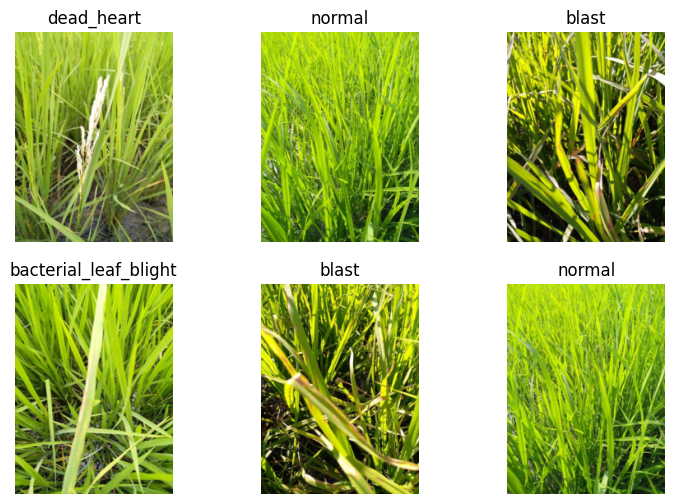

In [7]:
dls = ImageDataLoaders.from_folder(trn_path, valid_pct=0.2, seed=42,
                                  item_tfms=Resize((256, 192)))

dls.show_batch(max_n = 6)

In [8]:
def train(arch, item, batch, epochs=5):
    dls = ImageDataLoaders.from_folder(trn_path, valid_pct=0.2, seed=42,
                                      item_tfms=item, batch_tfms=batch)
    learn = vision_learner(dls, arch, metrics=error_rate).to_fp16()
    learn.fine_tune(epochs, 0.01)
    return learn

In [9]:
learn = train('resnet26d', item=Resize(192),
             batch=aug_transforms(size=128, min_scale=0.75))
# randomly takes out 128x128 sized image from the 192x192 in every epoch

model.safetensors:   0%|          | 0.00/64.2M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,error_rate,time
0,1.882213,1.499635,0.488707,00:48


epoch,train_loss,valid_loss,error_rate,time
0,1.241889,1.072938,0.361845,00:35
1,0.978182,0.661601,0.214320,00:35
2,0.687900,0.446305,0.147525,00:36
3,0.510991,0.359719,0.113888,00:36
4,0.426072,0.338761,0.103316,00:36


In [10]:
# lets try ConvNext
arch = 'convnext_small_in22k'
learn = train(arch=arch, item=Resize(192), batch=aug_transforms(size=128, min_scale=0.75))

/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name convnext_small_in22k to current convnext_small.fb_in22k.
  model = create_fn(


model.safetensors:   0%|          | 0.00/265M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,error_rate,time
0,1.279283,0.716291,0.242191,00:38


epoch,train_loss,valid_loss,error_rate,time
0,0.662224,0.423631,0.139356,00:42
1,0.545652,0.341364,0.106679,00:42
2,0.355327,0.258772,0.081211,00:42
3,0.226784,0.157027,0.047093,00:42
4,0.158902,0.146886,0.044690,00:43


## We can do a couple of things here:
1. Resizing images to lower size for faster training
2. Try a different model
3. Using padding on each item
4. Try Test Time Augmentation (TTA)

In [11]:
#Without tta, error rate
valid = learn.dls.valid
preds, true = learn.get_preds(dl=valid)

error_rate(preds, true)

TensorBase(0.0447)

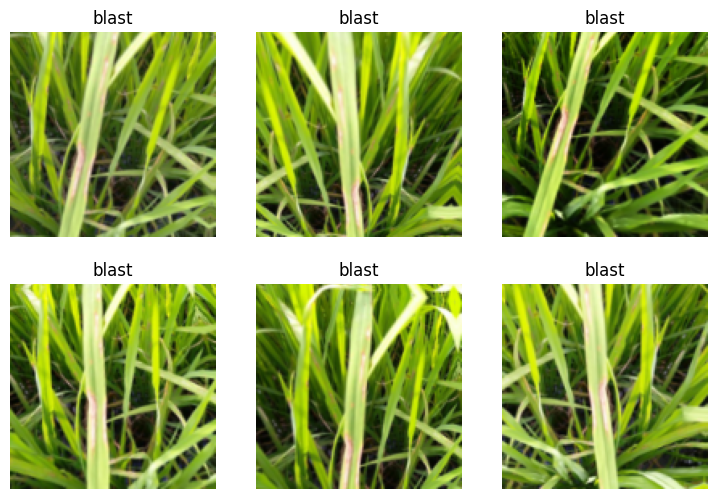

In [12]:
# with tta averaging
learn.dls.train.show_batch(max_n=6, unique=True)

In [13]:
tta_preds, _ = learn.tta(dl=valid)
error_rate(tta_preds, true)

TensorBase(0.0360)

## Now we train longer with the best configurations

In [15]:
learn = train(arch, epochs=12, 
              item=Resize((480, 360), method=ResizeMethod.Pad, pad_mode=PadMode.Zeros),
              batch=aug_transforms(size=(256, 192), min_scale=0.75))

epoch,train_loss,valid_loss,error_rate,time
0,1.101588,0.655618,0.187890,01:10


epoch,train_loss,valid_loss,error_rate,time
0,0.543109,0.290504,0.096108,01:28
1,0.375887,0.295441,0.095147,01:28
2,0.359307,0.323318,0.103316,01:28
3,0.297027,0.204023,0.064873,01:28
4,0.224470,0.181639,0.049015,01:28
5,0.168138,0.147579,0.035079,01:28
6,0.135298,0.126129,0.026910,01:28
7,0.098064,0.119198,0.030754,01:28
8,0.075196,0.106890,0.031235,01:28
9,0.058950,0.105553,0.025469,01:28


In [16]:
# Performing TTA

tta_preds, true = learn.tta(dl=learn.dls.valid)
error_rate(tta_preds, true)

TensorBase(0.0207)

## Ready for submission

In [17]:
tst_path = '/kaggle/input/paddy-disease-classification/test_images'
tst_files = get_image_files(tst_path).sorted()
len(tst_files)

3469

In [19]:
tst_dl = learn.dls.test_dl(tst_files)
tta_pred, _ = learn.get_preds(dl=tst_dl)

In [20]:
tta_pred.shape

torch.Size([3469, 10])

In [23]:
idxs = tta_pred.argmax(dim=1)
idxs.shape

torch.Size([3469])

In [24]:
# shorter way to map

vocab = np.array(learn.dls.vocab)
vocab

array(['bacterial_leaf_blight', 'bacterial_leaf_streak',
       'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart',
       'downy_mildew', 'hispa', 'normal', 'tungro'], dtype='<U24')

In [26]:
results = vocab[idxs]
results[:10]

array(['hispa', 'normal', 'blast', 'blast', 'blast', 'brown_spot',
       'dead_heart', 'brown_spot', 'hispa', 'normal'], dtype='<U24')

In [29]:
ss = pd.read_csv('/kaggle/input/paddy-disease-classification/sample_submission.csv')
ss['label'] = results
ss.to_csv("s3.csv", index=False)
!head s3.csv

image_id,label
200001.jpg,hispa
200002.jpg,normal
200003.jpg,blast
200004.jpg,blast
200005.jpg,blast
200006.jpg,brown_spot
200007.jpg,dead_heart
200008.jpg,brown_spot
200009.jpg,hispa
